# Entrenamiento — ValorAuto

Entrena y compara los 3 modelos definidos en `src/model/config.py` (`MODEL_HYPERPARAMS`), registra todo en MLflow, genera los graficos de evaluacion (comparacion, predicho vs real, residuos, curva de aprendizaje, importancia de features) y promueve el mejor modelo a Production. Notebook delgado: la logica vive en `src/model/training.py` y `src/model/evaluation.py` (ver [ADR-0008](../docs/adr/0008-separacion-componentes-notebooks-delgados.md)).

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Busca la raiz del repo subiendo desde `start` hasta encontrar `src/` y `notebooks/`.

    No asume un cwd fijo (a diferencia de `Path.cwd().parent`, que solo
    funciona si el notebook se lanzo con cwd=notebooks/): sirve tanto si
    Jupyter arranca con cwd en la carpeta del notebook como si se ejecuta
    con nbconvert/papermill desde la raiz del repo u otra carpeta.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError(
        "No se pudo ubicar la raiz del repo (se buscaron 'src/' y 'notebooks/' "
        f"subiendo desde {start})."
    )


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [2]:
from src.model import data_loading, evaluation, features, training


/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos y split

In [3]:
df_clean = data_loading.load_clean()
X_train, X_test, y_train, y_test = features.split_data(df_clean)
preprocessor = features.build_preprocessor()

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")


Train: 281604 filas | Test: 70401 filas


## 2. Entrenamiento de los 3 modelos (registrado en MLflow)

In [4]:
results = training.train_all_models(X_train, X_test, y_train, y_test, preprocessor)

for nombre, r in results.items():
    print(f"[{nombre}] RMSE={r['rmse']:.2f}  MAE={r['mae']:.2f}  R2={r['r2']:.4f}")


2026/09/17 19:33:41 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



2026/09/17 19:33:41 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git branch is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



2026/09/17 19:33:41 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git repository URL is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



/usr/local/lib/python3.10/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


/usr/local/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this 

...

/usr/local/lib/python3.10/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


/usr/local/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this 

/usr/local/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/09/17 19:34:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/09/17 19:34:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Baseline_LinearRegression] RMSE=8107.91  MAE=5587.19  R2=0.6716
[Model_RandomForest] RMSE=7048.09  MAE=4566.73  R2=0.7518
[Model_XGBoost] RMSE=6085.26  MAE=3777.90  R2=0.8150


## 3. Evaluacion — graficos

En vez de quedarse solo en los prints de arriba, cada modelo genera sus graficos de evaluacion en `src/graphics/evaluacion/` y quedan logueados como artifacts del run de MLflow correspondiente.

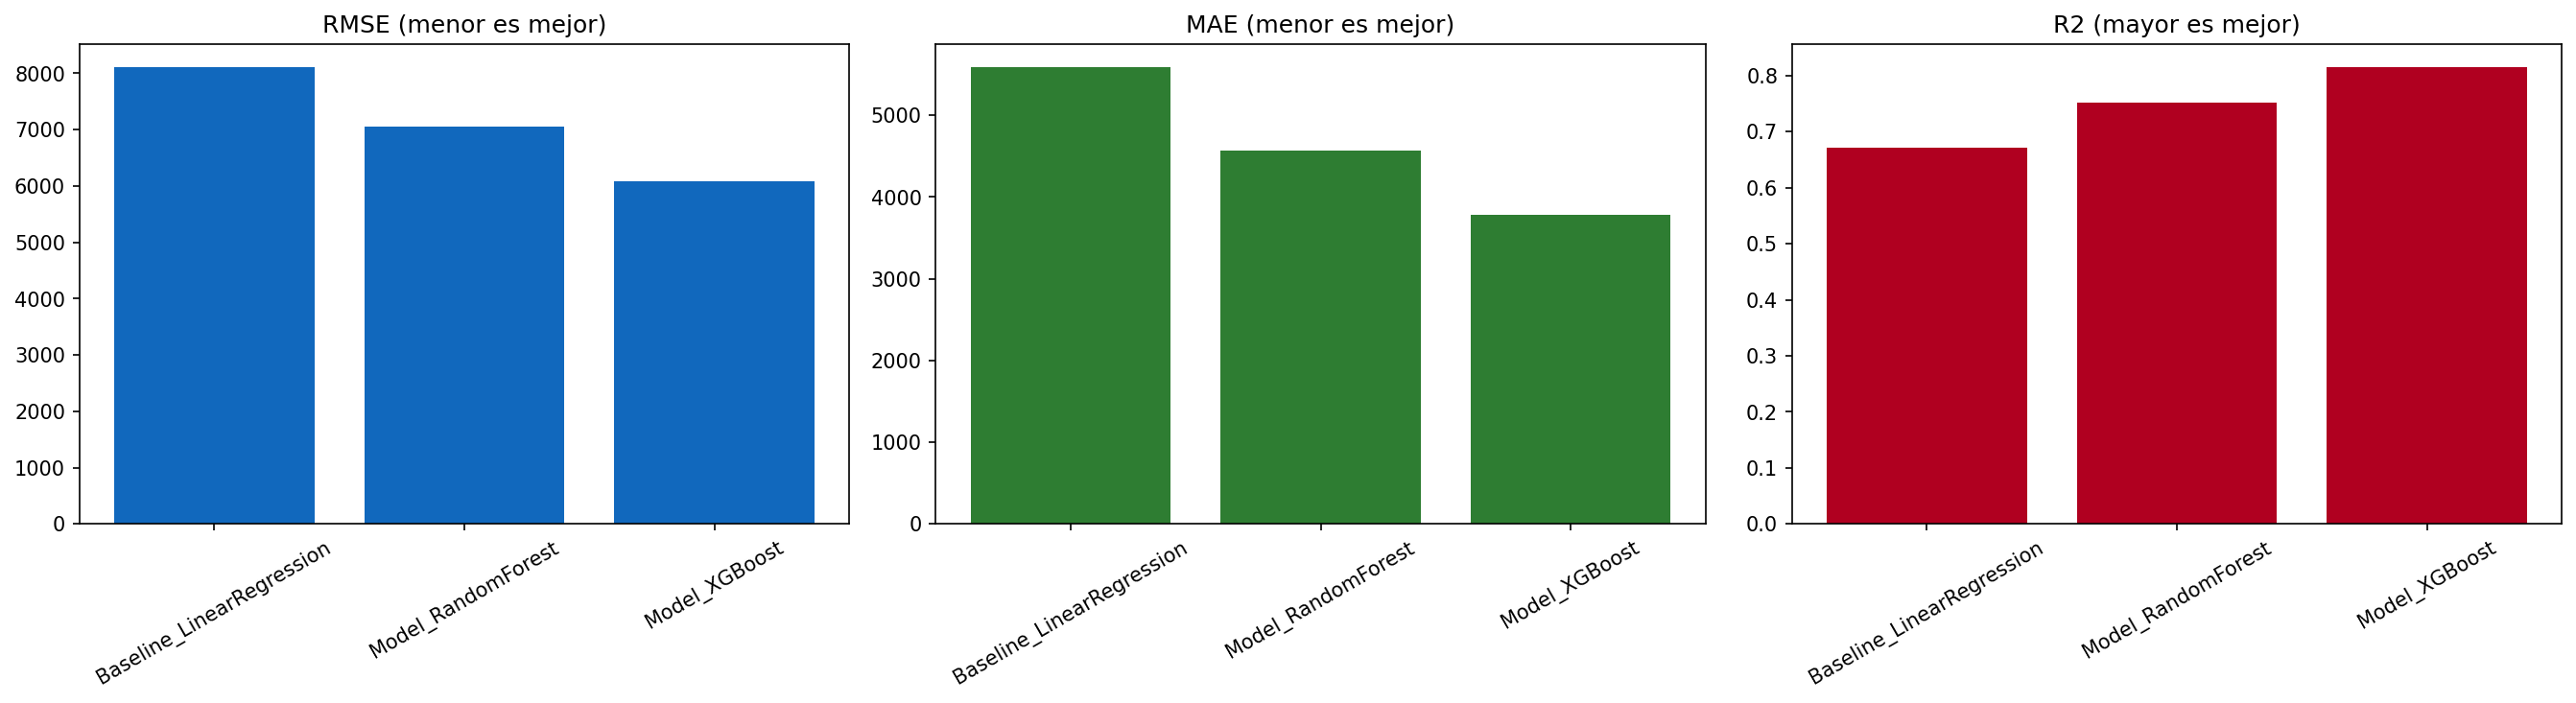

In [5]:
from IPython.display import Image, display

ruta_comparacion = evaluation.graficar_comparacion_metricas(results)
display(Image(filename=ruta_comparacion))


--- Baseline_LinearRegression ---


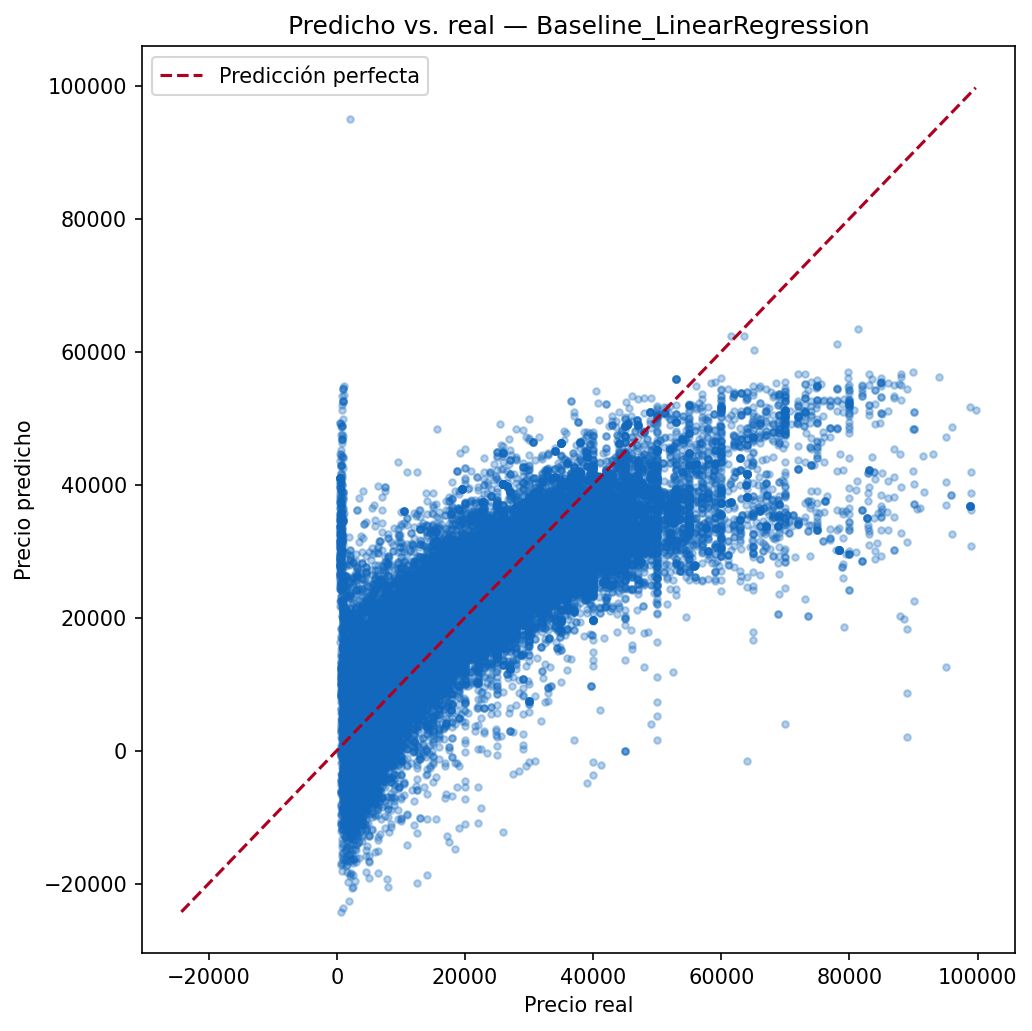

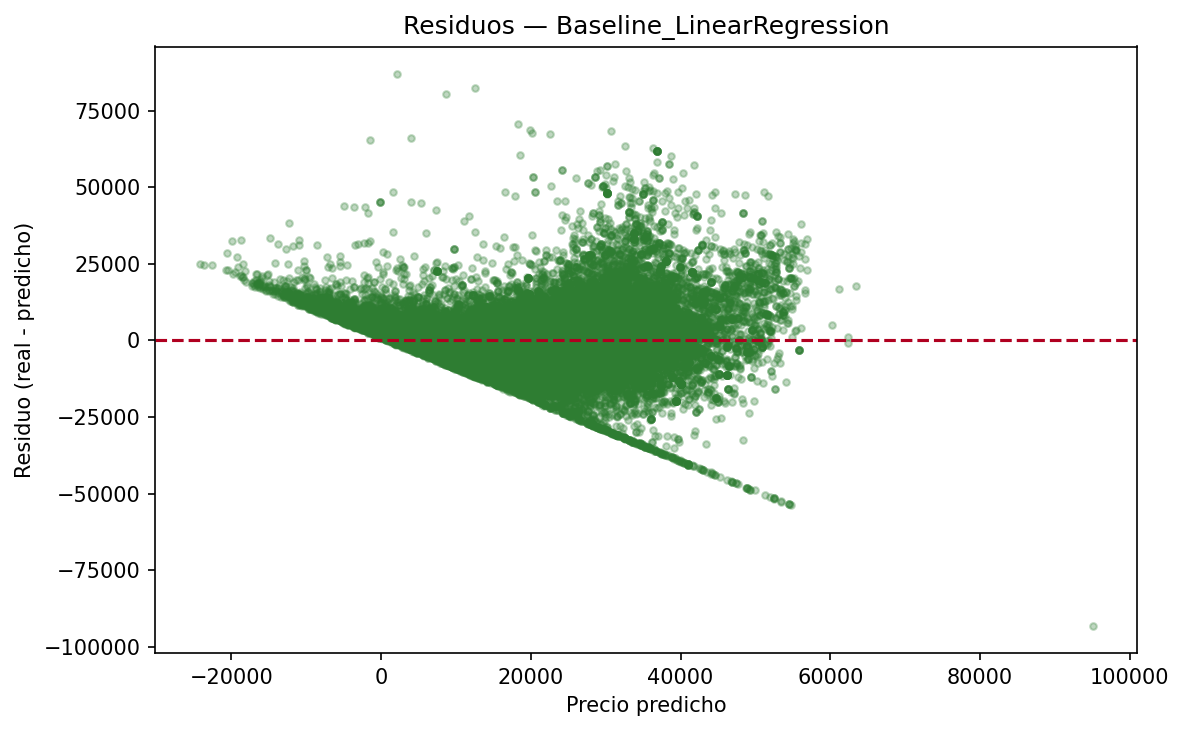

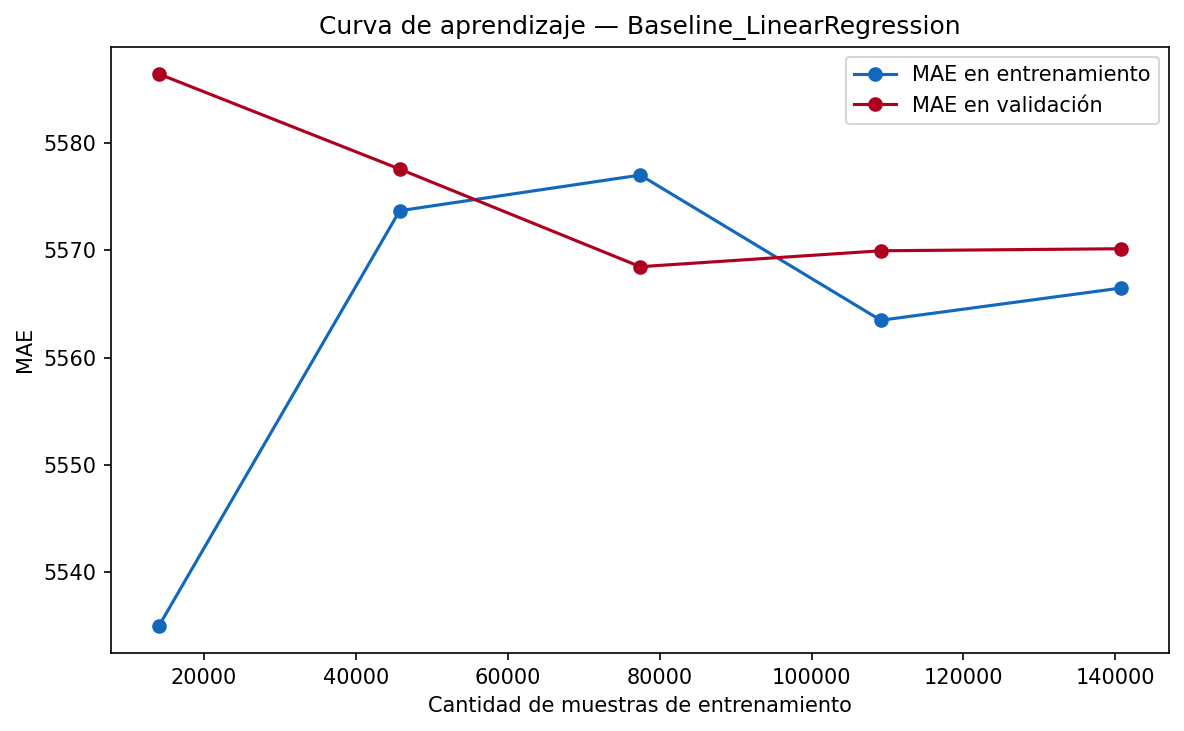

--- Model_RandomForest ---


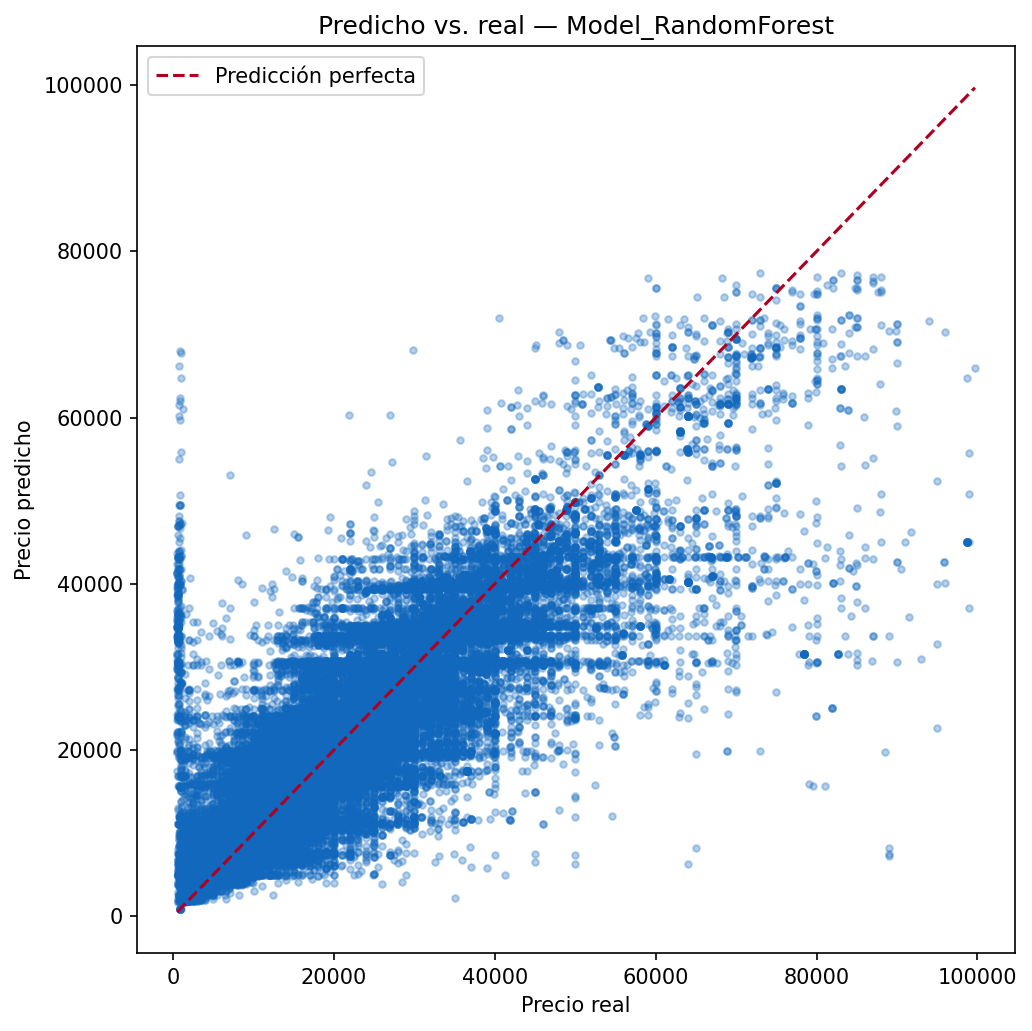

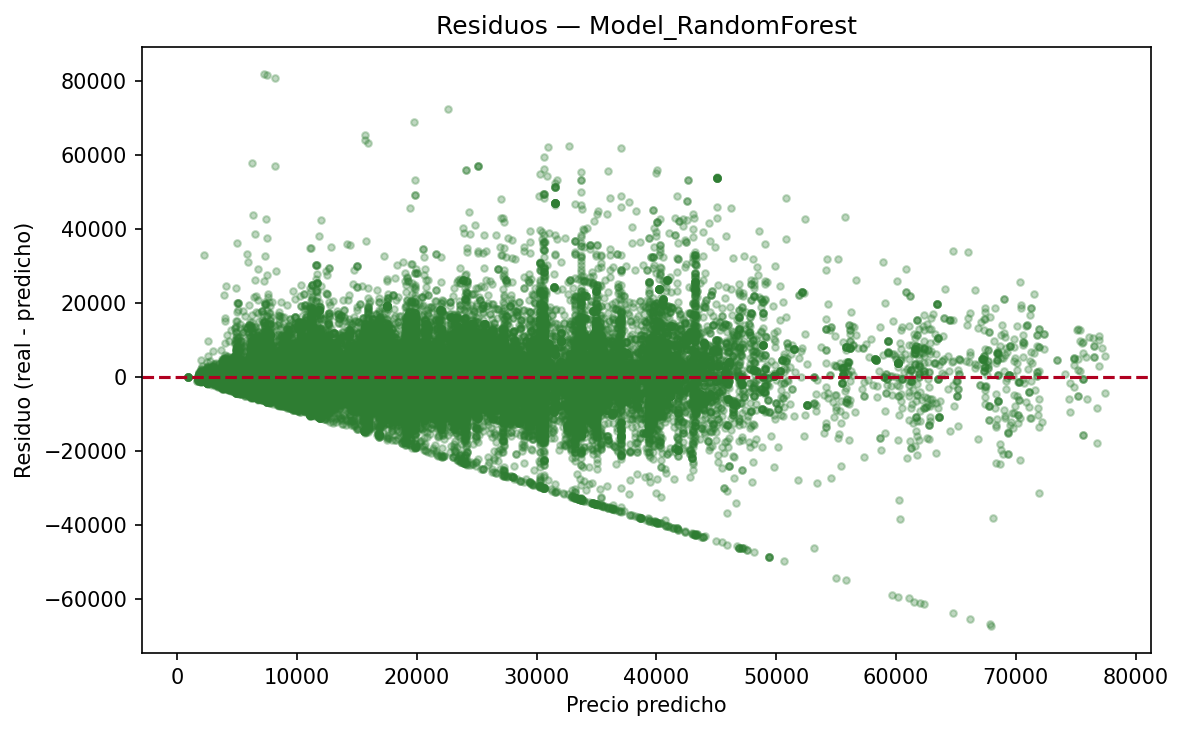

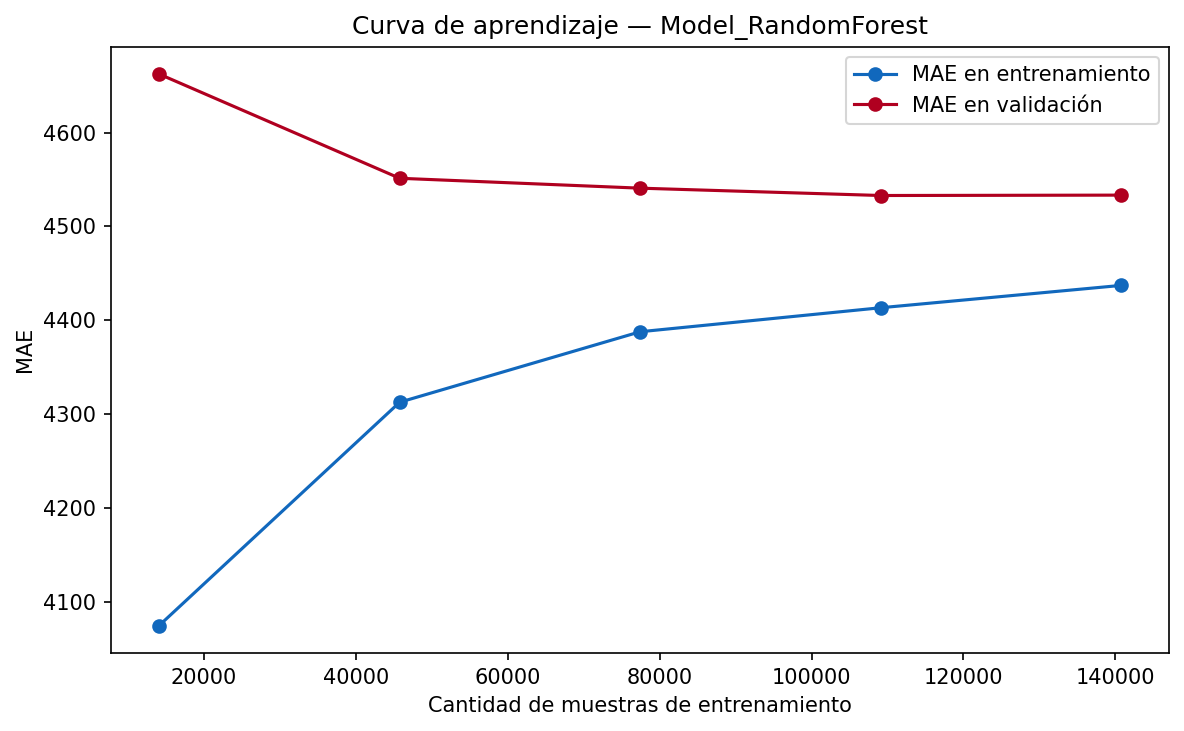

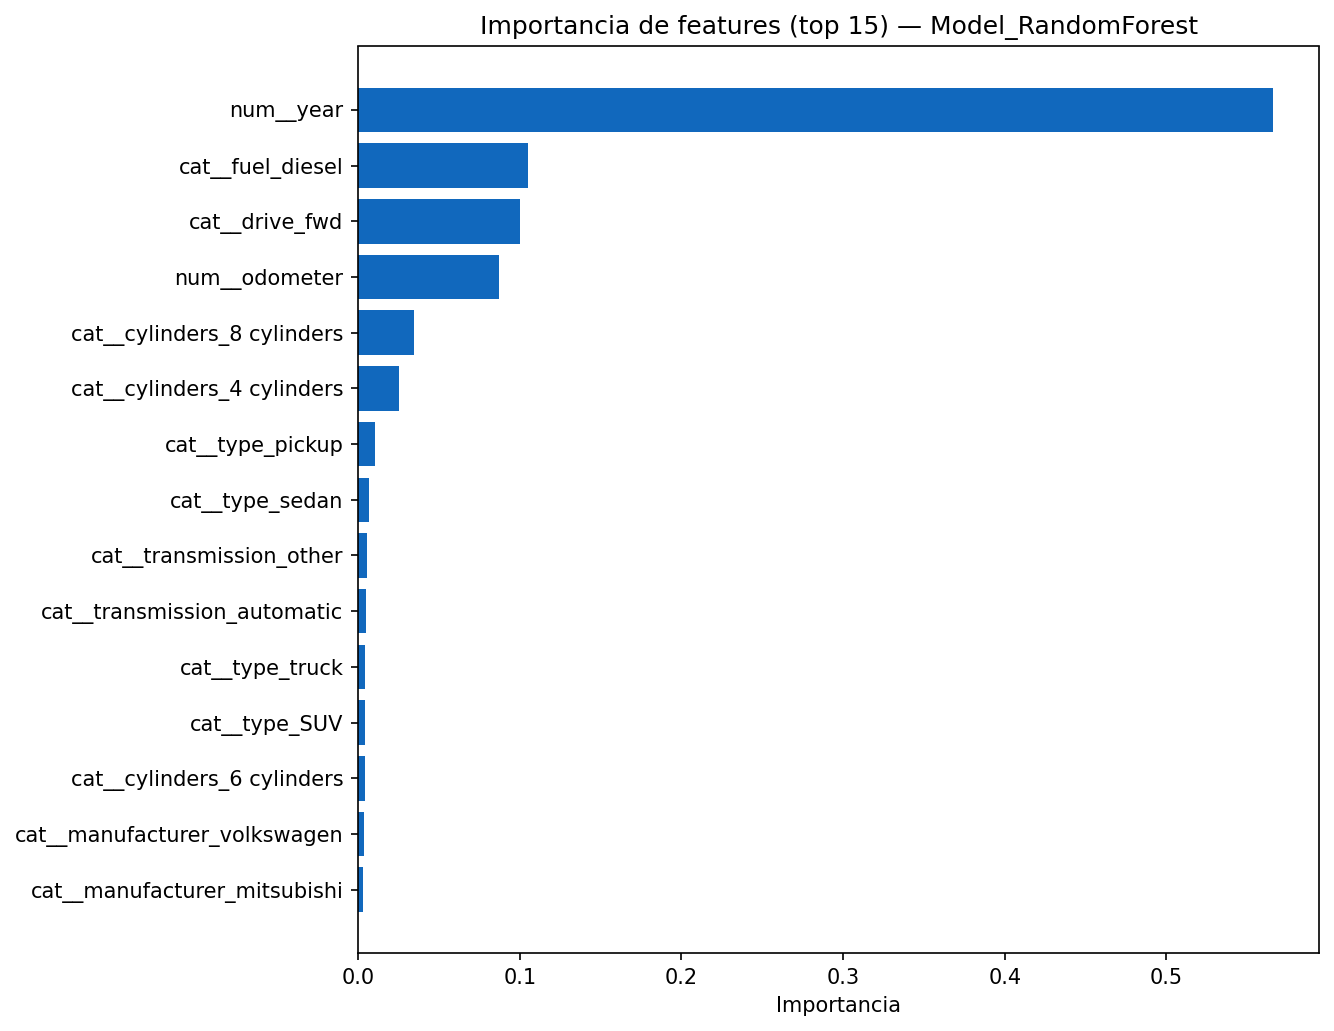

--- Model_XGBoost ---


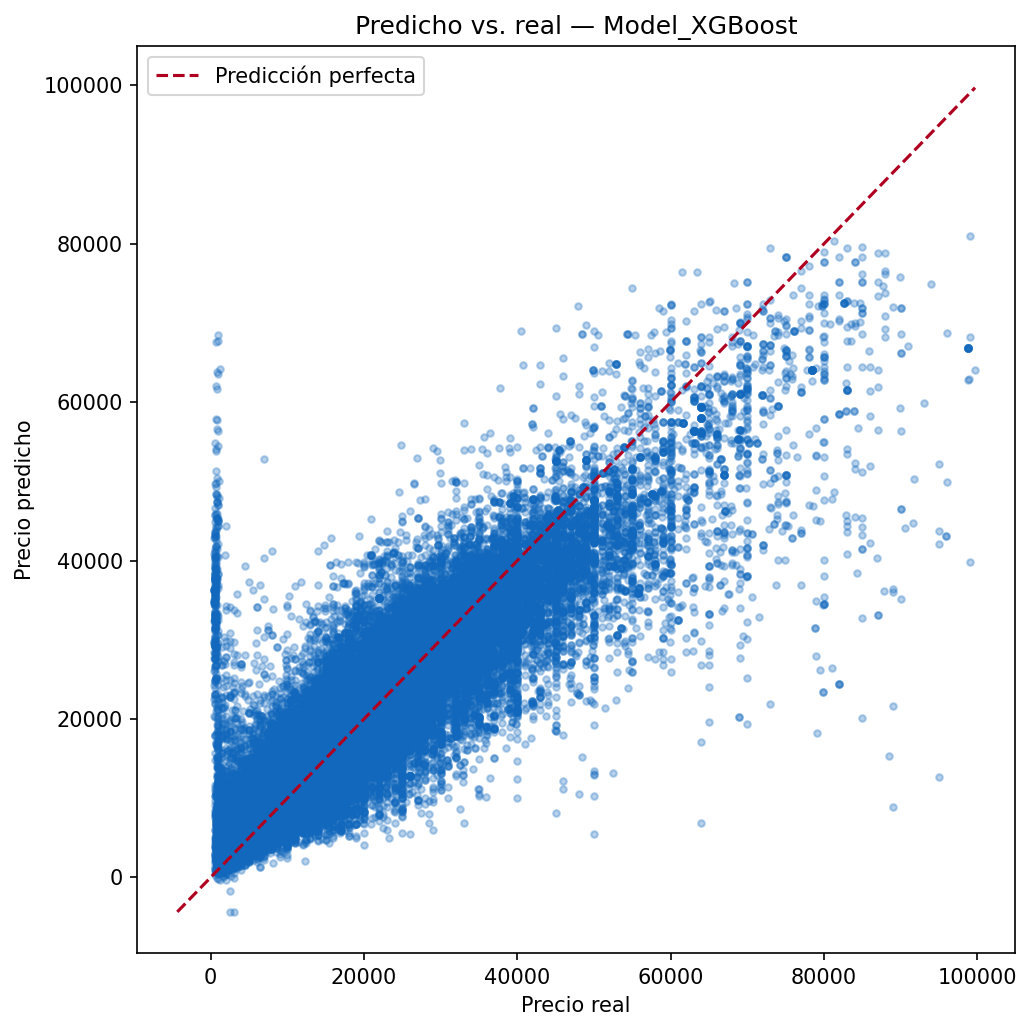

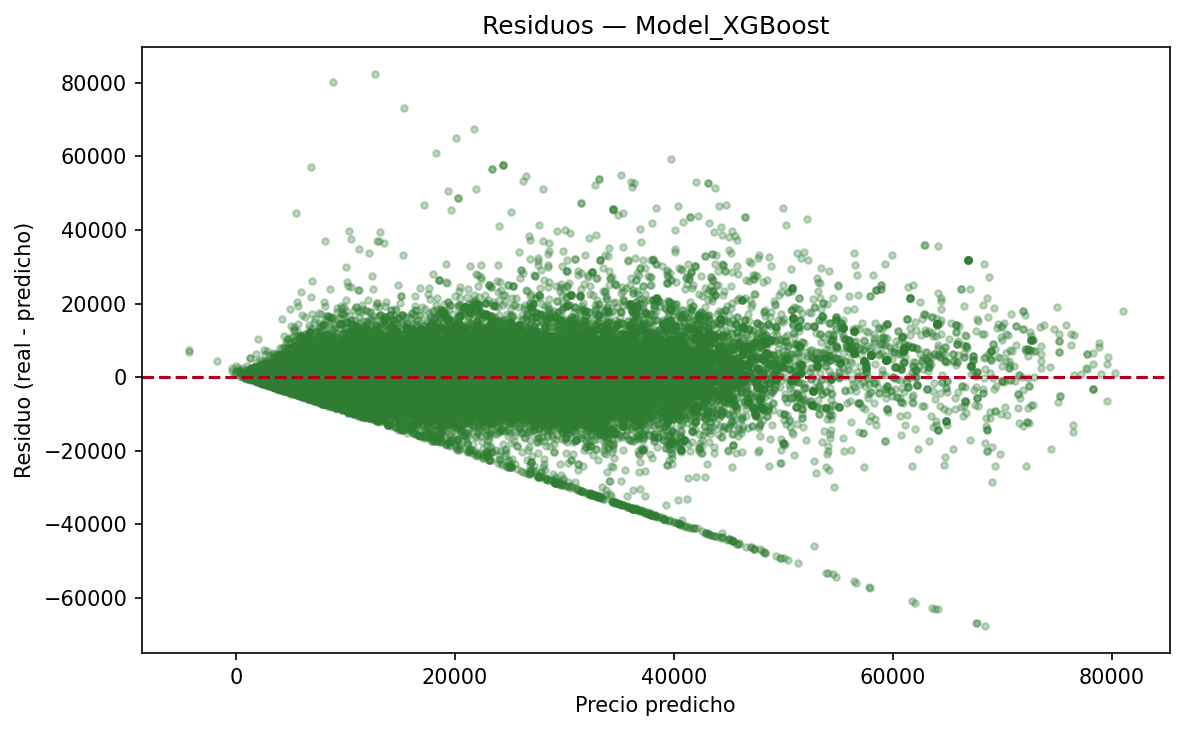

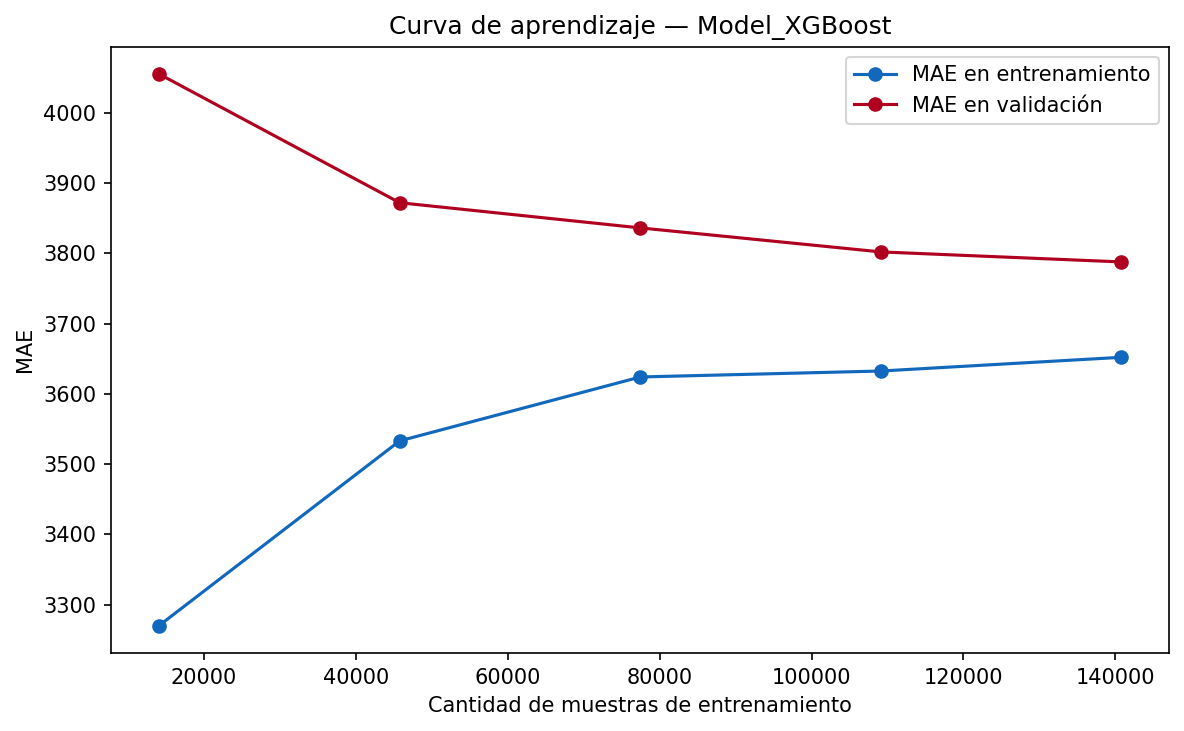

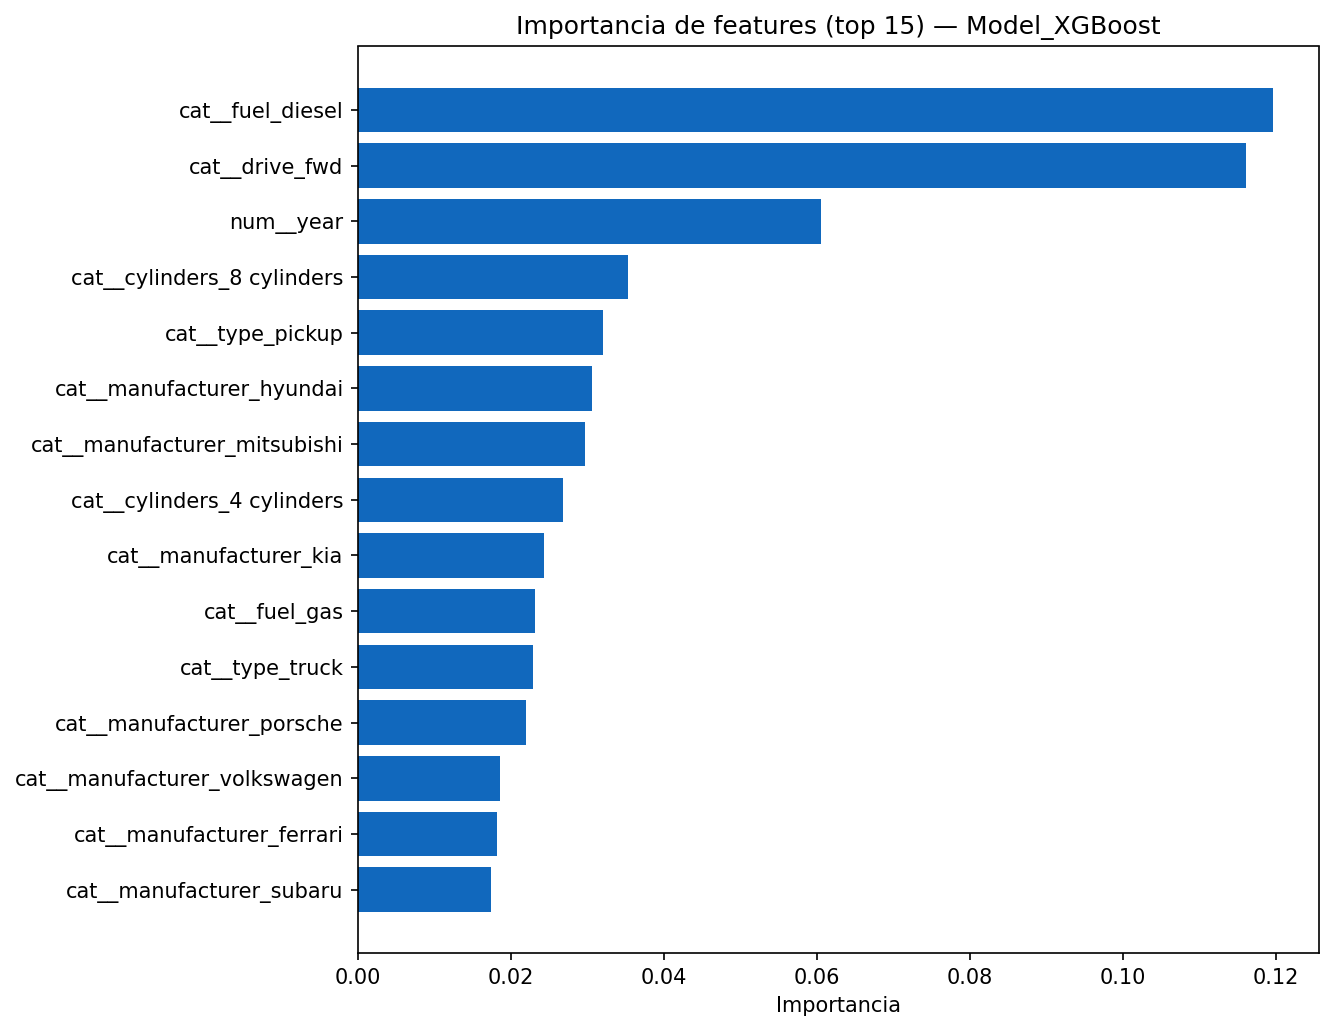

In [6]:
for nombre, r in results.items():
    print(f"--- {nombre} ---")
    display(Image(filename=evaluation.graficar_predicho_vs_real(y_test, r["y_pred"], nombre, r["run_id"])))
    display(Image(filename=evaluation.graficar_residuos(y_test, r["y_pred"], nombre, r["run_id"])))
    display(Image(filename=evaluation.graficar_curva_aprendizaje(r["pipeline"], X_train, y_train, nombre, r["run_id"])))
    ruta_importancia = evaluation.graficar_importancia_features(r["pipeline"], nombre, r["run_id"])
    if ruta_importancia:
        display(Image(filename=ruta_importancia))


## 4. Promocion del mejor modelo a Production

In [7]:
mejor_nombre, version = training.promote_best_model(results)
print(f"Mejor modelo: {mejor_nombre} -> version {version} promovida a Production en el Model Registry")


Registered model 'ValorAuto_Model' already exists. Creating a new version of this model...
2026/09/17 19:35:48 WARNING mlflow.tracking._model_registry.fluent: Run with id 4a0c3b451e4345f59309bb422f669059 has no artifacts at artifact path 'model', registering model based on models:/m-4e4e9af56a514fc9a15a748880fc5211 instead


Mejor modelo: Model_XGBoost -> version 4 promovida a Production en el Model Registry


Created version '4' of model 'ValorAuto_Model'.
/app/src/model/training.py:140: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


## 5. Tabla resumen de resultados

Todos los modelos entrenados, con sus metricas finales, ordenados de mejor a peor (menor RMSE primero). El grafico de comparacion de la seccion 3 muestra esto visualmente; esta tabla deja los numeros exactos a la vista sin tener que abrir MLflow.

In [8]:
import pandas as pd

tabla_resultados = pd.DataFrame([
    {"Modelo": nombre, "RMSE": r["rmse"], "MAE": r["mae"], "R2": r["r2"]}
    for nombre, r in results.items()
]).sort_values("RMSE").reset_index(drop=True)

tabla_resultados

,Modelo,RMSE,MAE,R2
0,Model_XGBoost,6085.262854,3777.897705,0.815012
1,Model_RandomForest,7048.089752,4566.728019,0.751843
2,Baseline_LinearRegression,8107.905122,5587.192299,0.671601
